In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [3]:
# creating database connection
conn = sqlite3.connect('inventory.db')

In [5]:
# fetching vendor summary data
df = pd.read_sql_query('select * from vendor_sales_summary', conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,TotalPurchaseQuantity,TotalPurchaseDollars,TotalFreightCost
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750,9578.0,344712.22,64889.97,17598.14,145080,3811251.60,68601.68
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750,9203.0,275162.97,52289.50,16909.12,164038,3804041.22,144929.24
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750,11189.0,288135.11,48202.30,20557.97,187407,3418303.68,123780.22
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750,20226.0,444810.74,43304.31,37163.76,201682,3261197.94,257032.07
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750,11883.0,357759.17,52774.51,21833.58,138109,3023206.01,257032.07


In [6]:
#summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,10650.649458,18753.519148,2.00,3951.0000,7153.000,9552.0000,201359.00
Brand,10692.0,18039.228769,12662.187074,58.00,5793.5000,18761.500,25514.2500,90631.00
PurchasePrice,10692.0,24.385303,109.269375,0.36,6.8400,10.455,19.4825,5681.81
ActualPrice,10692.0,35.643671,148.246016,0.49,10.9900,15.990,28.9900,7499.99
TotalSalesQuantity,7144.0,342.562850,1047.307202,1.00,12.0000,61.000,270.0000,28544.00
TotalSalesDollars,7144.0,4624.092104,14662.388203,1.98,249.8175,1119.230,4053.4850,444810.74
TotalSalesPrice,7144.0,2257.384103,4593.699964,0.98,125.8800,635.445,2422.3300,64889.97
TotalExciseTax,7144.0,194.596923,1031.268200,0.02,1.9100,11.825,68.6425,37163.76
TotalPurchaseQuantity,10692.0,3140.886831,11095.086769,1.00,36.0000,262.000,1975.7500,337660.00
TotalPurchaseDollars,10692.0,30106.693372,123067.799627,0.71,453.4575,3655.465,20738.2450,3811251.60


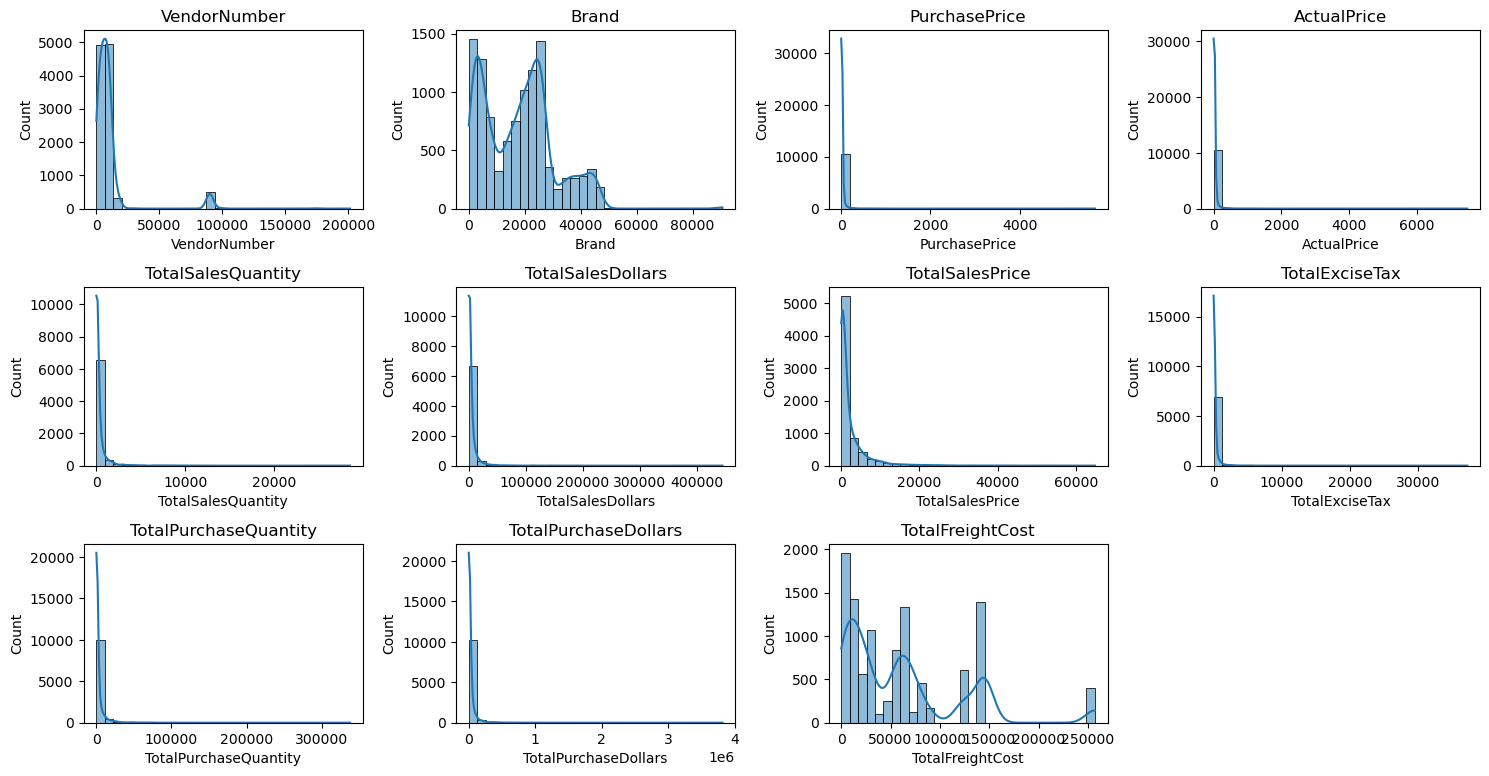

In [8]:
# Distribution plot for Numerical Columns
numerical_cols = df.select_dtypes(include = np.number).columns
plt.figure(figsize = (15,10))
for i , col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

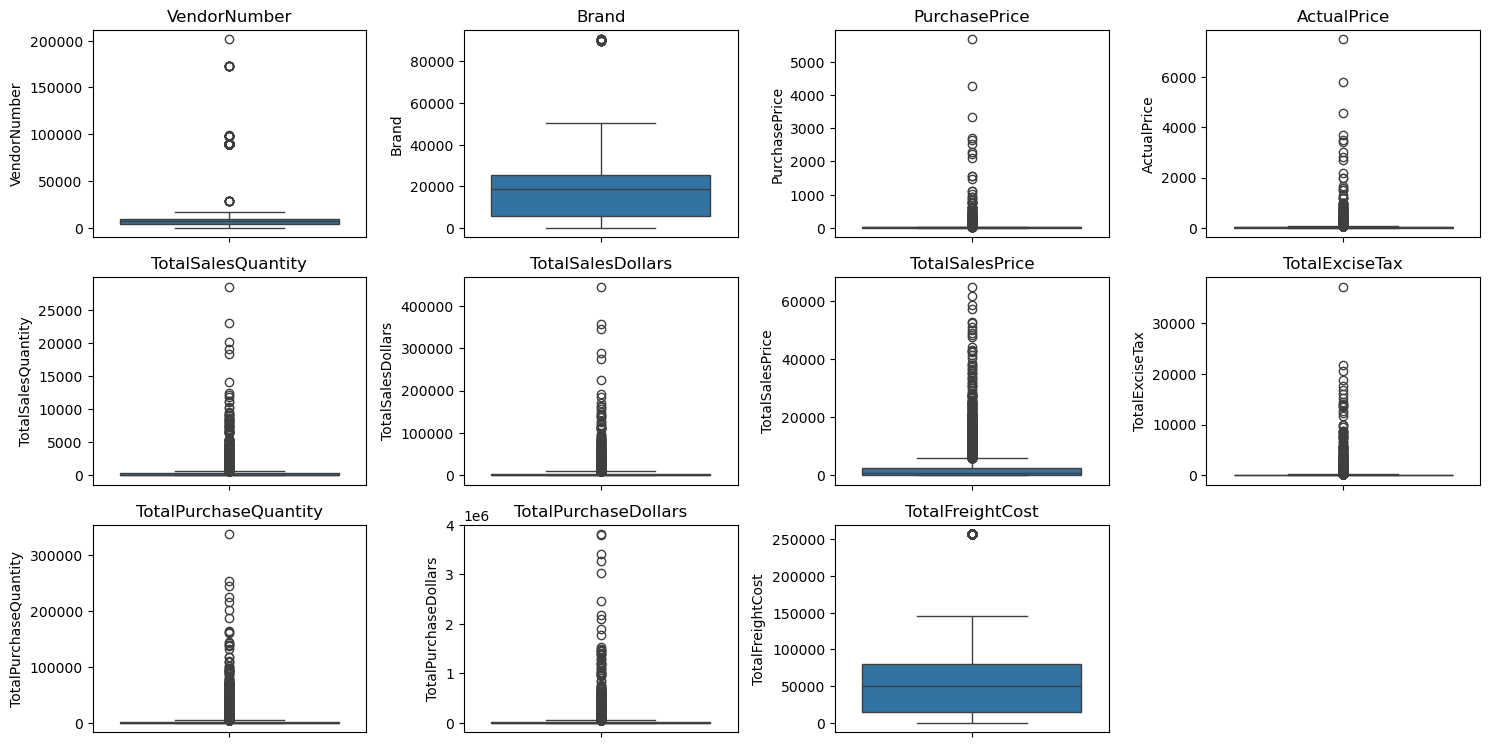

In [9]:
# Outliers Detection with Boxplots
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [21]:

conn.execute("""UPDATE vendor_sales_summary SET GrossProfit = TotalSalesDollars - TotalPurchaseDollars - TotalFreightCost""")
conn.commit()

In [22]:
conn.execute("ALTER TABLE vendor_sales_summary ADD COLUMN profitMargin REAL")
conn.execute("""UPDATE vendor_sales_summary SET ProfitMargin = (TotalSalesDollars - TotalPurchaseDollars - TotalFreightCost)*1.0/TotalSalesDollars""")
conn.commit()

In [23]:
# Let's filter the data bu removing inconsistencies
df = pd.read_sql_query("""SELECT * FROM vendor_sales_summary WHERE GrossProfit > 0 AND ProfitMargin > 0 
                          AND TotalSalesQuantity > 0""", conn)
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,TotalPurchaseQuantity,TotalPurchaseDollars,TotalFreightCost,GrossProfit,profitMargin
0,2555,DISARONNO INTERNATIONAL LLC,1212,DiSaronna Amaretto Sour VAP,14.38,21.99,750,717.0,15596.83,8230.22,564.77,563,8095.94,5861.03,1639.86,0.105141
1,90047,CRUSH WINES,23218,Tangent Chard,6.70,9.99,750,700.0,6993.00,3086.91,78.00,663,4442.10,1457.73,1093.17,0.156323
2,653,STATE WINE & SPIRITS,23256,Robert Hall Cab Svgn,9.39,13.99,750,923.0,12912.77,4784.58,103.14,442,4150.38,8014.98,747.41,0.057881
3,1703,ALISA CARR BEVERAGES,90089,Ch Lynch Bages 12 Pauillac,77.92,119.99,750,27.0,3239.73,599.95,3.03,32,2493.44,172.00,574.29,0.177265
4,90017,THE IMPORTED GRAPE LLC,42797,Ricardo Santos Malbec Mendza,10.64,18.49,750,41.0,682.09,86.45,4.60,48,510.72,80.03,91.34,0.133912
5,1703,ALISA CARR BEVERAGES,90080,Ch Cantenac Brown Margaux 11,40.26,59.99,750,19.0,1139.81,179.97,2.14,8,322.08,172.00,645.73,0.566524
6,90024,VINILANDIA USA,16370,Zinsane Znfdl Lodi,5.44,7.99,750,1017.0,8125.83,3459.67,113.43,44,239.36,2802.64,5083.83,0.625638
7,5455,MARSALLE COMPANY,3539,MacGavin's Highland Scotch,13.13,24.99,750,81.0,1457.19,1061.41,63.86,6,78.78,937.21,441.20,0.302775
8,5612,MILTONS DISTRIBUTING CO,17816,Sauvignon Republic Svgn Bl,5.86,8.79,750,11.0,96.69,8.79,1.24,12,70.32,9.46,16.91,0.174889
9,1439,CAPSTONE INTERNATIONAL,2213,King Robert II Scotch Whisky,13.66,26.99,1750,12.0,227.88,94.95,22.05,4,54.64,0.27,172.97,0.759040


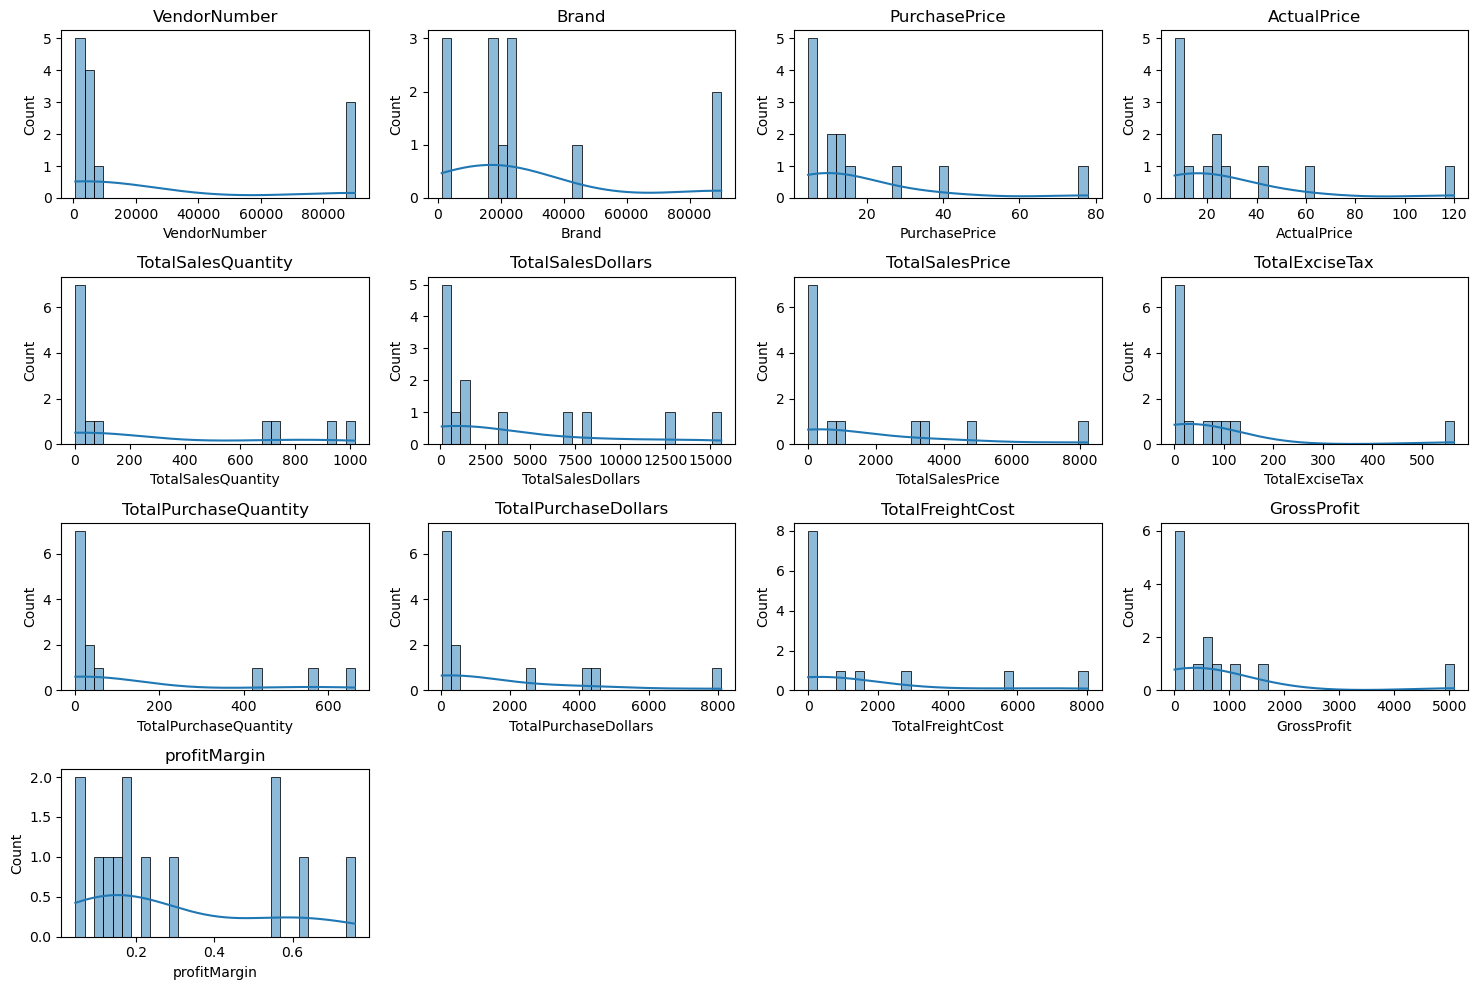

In [24]:
# Distribution plot for Numerical Columns
numerical_cols = df.select_dtypes(include = np.number).columns
plt.figure(figsize = (15,10))
for i , col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

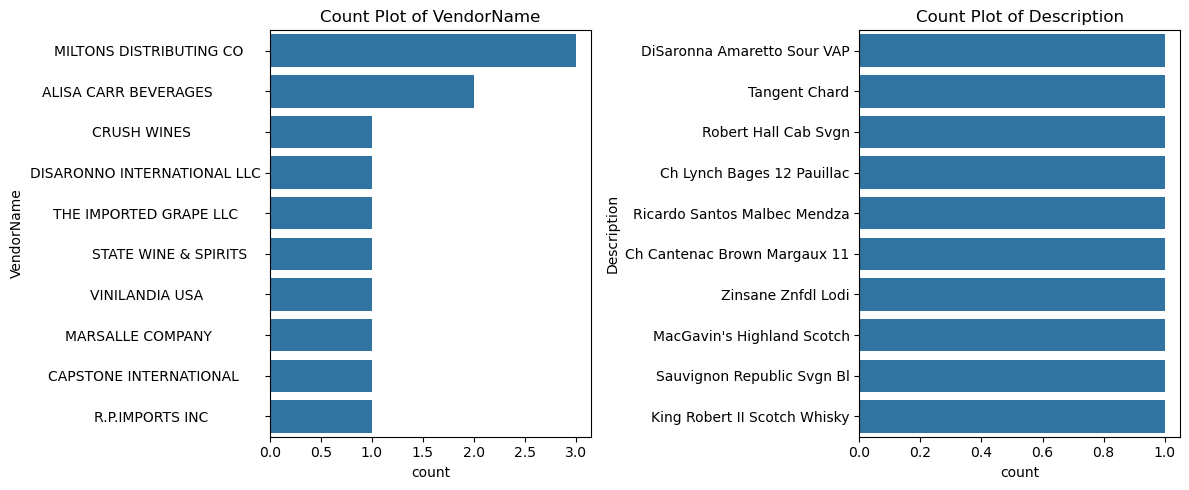

In [26]:
#Count plots for Categorical Columns
categorical_cols = ["VendorName","Description"]
plt.figure(figsize=(12,5))
for i , col in enumerate(categorical_cols):
    plt.subplot(1,2,i+1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10])
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

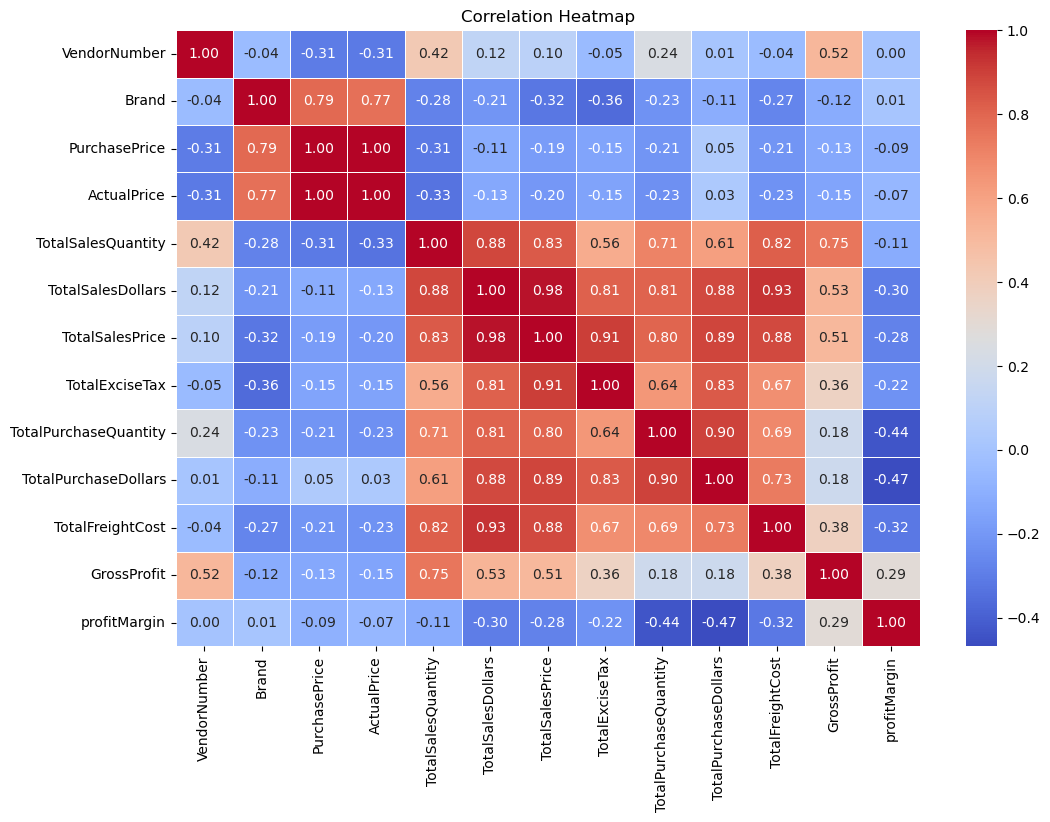

In [28]:
# correlation heatmap
plt.figure(figsize=(12,8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidth=0.5)
plt.title("Correlation Heatmap")
plt.show()

## Data Analysis
Identify Brands that needs Promotional or Pricing Adjustments which exhibits lower sales performance but higher profit margins. 

In [31]:
df = pd.read_sql("select * from vendor_sales_summary", conn)

In [100]:
print(df.columns)

Index(['VendorNumber', 'VendorName', 'Brand', 'Description', 'PurchasePrice',
       'ActualPrice', 'Volume', 'TotalSalesQuantity', 'TotalSalesDollars',
       'TotalSalesPrice', 'TotalExciseTax', 'TotalPurchaseQuantity',
       'TotalPurchaseDollars', 'TotalFreightCost', 'GrossProfit',
       'profitMargin', 'UnitPurchasePrice', 'OrderSize'],
      dtype='object')


In [34]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars':'sum','profitMargin':'mean'}).reset_index()

In [35]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['profitMargin'].quantile(0.85)

In [36]:
low_sales_threshold

np.float64(0.0)

In [37]:
high_margin_threshold

np.float64(-11.42979566766027)

In [38]:
# filter brands with low sales but high profit margin 
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['profitMargin'] >= high_margin_threshold)]
print("Brands with Low Sales but High Profit Margins")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low Sales but High Profit Margins


,Description,TotalSalesDollars,profitMargin


In [46]:
brand_performance = brand_performance[brand_performance['TotalSalesDollars']<1000]

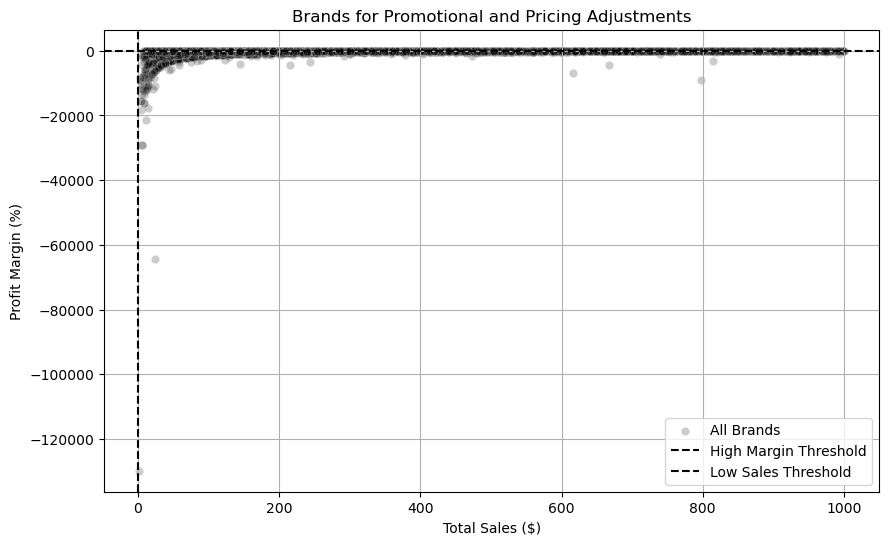

In [98]:
plt.figure(figsize = (10,6))
sns.scatterplot(data=brand_performance,
                x='TotalSalesDollars',
                y='profitMargin',
                color="black",
                label="All Brands",
                alpha=0.2)
sns.scatterplot(data=target_brands,
                x='TotalSalesDollars',
                y='profitMargin',
                color="red",
                label="Target Brands")
plt.axhline(high_margin_threshold,
            linestyle='--',
            color="black",
            label="High Margin Threshold")
plt.axvline(low_sales_threshold,
            linestyle='--',
            color="black",
            label="Low Sales Threshold")
plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional and Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

Which Vendors and Brands demonstrate the higher sales performance?

In [68]:
def format_dollars(value):
    if value >= 10_000_000:
        return f"{value/10_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value/1_000:.2f}K"
    else:
         return str(value)

In [69]:
# top vendors & brands by sales performance
top_vendors = df.groupby("VendorName")['TotalSalesDollars'].sum().nlargest(10)
top_brands = df.groupby("Description")['TotalSalesDollars'].sum().nlargest(10)
top_vendors

VendorName
DIAGEO NORTH AMERICA INC       4831666.43
MARTIGNETTI COMPANIES          3086438.23
JIM BEAM BRANDS COMPANY        2516806.65
PERNOD RICARD USA              2215113.82
CONSTELLATION BRANDS INC       1878159.16
BACARDI USA INC                1657331.00
E & J GALLO WINERY             1526350.26
ULTRA BEVERAGE COMPANY LLP     1395710.15
BROWN-FORMAN CORP              1348737.75
M S WALKER INC                 1292437.12
Name: TotalSalesDollars, dtype: float64

In [70]:
top_vendors.apply(lambda x: format_dollars(x))

VendorName
DIAGEO NORTH AMERICA INC       4831.67K
MARTIGNETTI COMPANIES          3086.44K
JIM BEAM BRANDS COMPANY        2516.81K
PERNOD RICARD USA              2215.11K
CONSTELLATION BRANDS INC       1878.16K
BACARDI USA INC                1657.33K
E & J GALLO WINERY             1526.35K
ULTRA BEVERAGE COMPANY LLP     1395.71K
BROWN-FORMAN CORP              1348.74K
M S WALKER INC                 1292.44K
Name: TotalSalesDollars, dtype: object

In [71]:
top_brands

Description
Capt Morgan Spiced Rum     610008.34
Jack Daniels No 7 Black    558064.03
Absolut 80 Proof           422095.29
Tito's Handmade Vodka      420186.25
Ketel One Vodka            417950.59
Jameson Irish Whiskey      410287.84
Grey Goose Vodka           394280.19
Baileys Irish Cream        294738.43
Kahlua                     290933.11
Jim Beam                   255837.61
Name: TotalSalesDollars, dtype: float64

In [72]:
top_brands.apply(lambda x: format_dollars(x))

Description
Capt Morgan Spiced Rum     610.01K
Jack Daniels No 7 Black    558.06K
Absolut 80 Proof           422.10K
Tito's Handmade Vodka      420.19K
Ketel One Vodka            417.95K
Jameson Irish Whiskey      410.29K
Grey Goose Vodka           394.28K
Baileys Irish Cream        294.74K
Kahlua                     290.93K
Jim Beam                   255.84K
Name: TotalSalesDollars, dtype: object

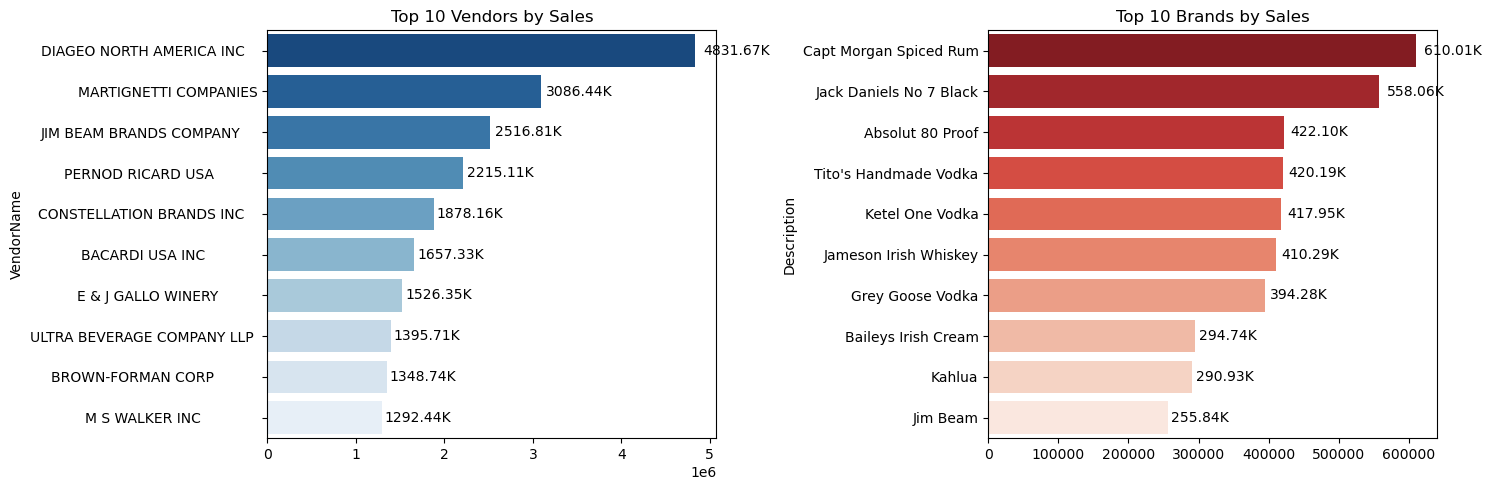

In [75]:
plt.figure(figsize=(15,5))
# plot for top vendors
plt.subplot(1,2,1)
ax1 = sns.barplot(y=top_vendors.index, 
                  x=top_vendors.values,
                  palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() *0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color="black")

# plot for top brands
plt.subplot(1,2,2)
ax2 = sns.barplot(y=top_brands.index.astype(str), 
                  x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() *0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color="black")

plt.tight_layout()
plt.show()

Which Vendors contribute the most to total purchase dollars?

In [76]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'}).reset_index()

In [77]:
vendor_performance['PurchaseContribution%']=vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum()*100
vendor_performance=round(vendor_performance.sort_values('PurchaseContribution%',ascending = False),2)

In [81]:
# display Top 10 Vendors
top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars']=top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars']=top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit']=top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
28,DIAGEO NORTH AMERICA INC,5.10M,-126361138.41,4831.67K,15.83
63,MARTIGNETTI COMPANIES,2.78M,-158465335.42,3086.44K,8.64
50,JIM BEAM BRANDS COMPANY,2.42M,-58550760.39,2516.81K,7.52
75,PERNOD RICARD USA,2.41M,-47733315.0,2215.11K,7.49
8,BACARDI USA INC,1.76M,-28339673.59,1657.33K,5.48
23,CONSTELLATION BRANDS INC,1.56M,-40982790.17,1878.16K,4.84
14,BROWN-FORMAN CORP,1.35M,-18540162.45,1348.74K,4.20
115,ULTRA BEVERAGE COMPANY LLP,1.32M,-44651136.66,1395.71K,4.10
33,E & J GALLO WINERY,1.23M,-32818126.58,1526.35K,3.82
59,M S WALKER INC,1.09M,-37741037.35,1292.44K,3.40


In [82]:
top_vendors['PurchaseContribution%'].sum()


np.float64(65.32)

In [84]:
top_vendors['Cumulative_Contribution%']=top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_Contribution%
28,DIAGEO NORTH AMERICA INC,5.10M,-126361138.41,4831.67K,15.83,15.83
63,MARTIGNETTI COMPANIES,2.78M,-158465335.42,3086.44K,8.64,24.47
50,JIM BEAM BRANDS COMPANY,2.42M,-58550760.39,2516.81K,7.52,31.99
75,PERNOD RICARD USA,2.41M,-47733315.0,2215.11K,7.49,39.48
8,BACARDI USA INC,1.76M,-28339673.59,1657.33K,5.48,44.96
23,CONSTELLATION BRANDS INC,1.56M,-40982790.17,1878.16K,4.84,49.80
14,BROWN-FORMAN CORP,1.35M,-18540162.45,1348.74K,4.20,54.00
115,ULTRA BEVERAGE COMPANY LLP,1.32M,-44651136.66,1395.71K,4.10,58.10
33,E & J GALLO WINERY,1.23M,-32818126.58,1526.35K,3.82,61.92
59,M S WALKER INC,1.09M,-37741037.35,1292.44K,3.40,65.32


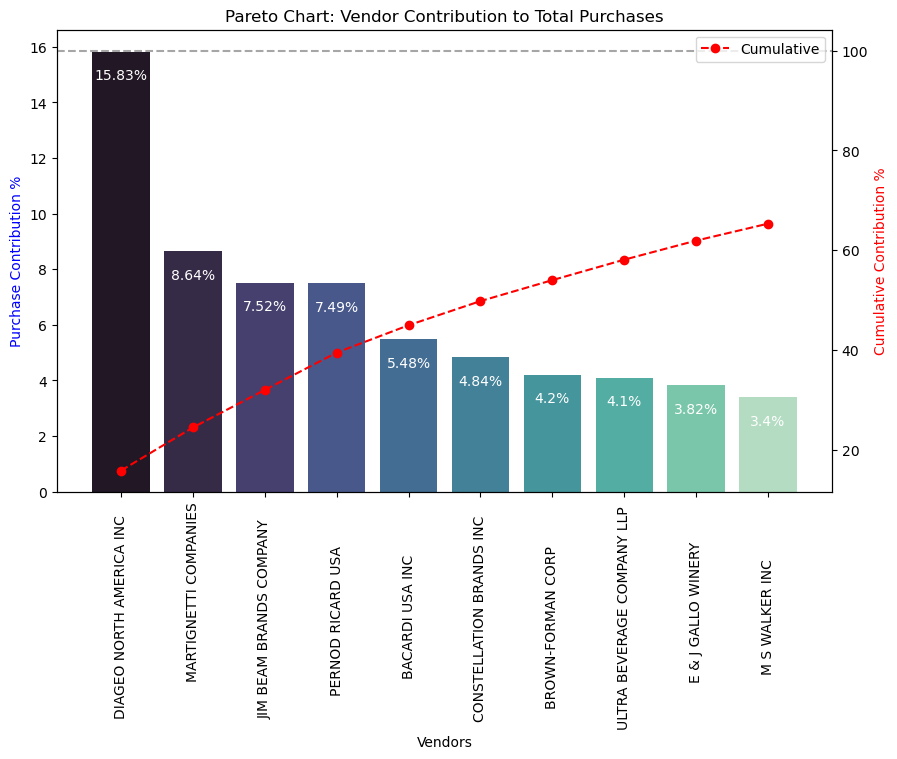

In [86]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution%
sns.barplot(x=top_vendors['VendorName'], y=top_vendors['PurchaseContribution%'], palette="mako", ax=ax1)

for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i, value - 1, str(value) + '%', ha='center', fontsize=10, color='white')

# Line Plot for Cumulative Contribution%
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['Cumulative_Contribution%'], color='red', marker='o', linestyle='dashed', label='Cumulative')

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')

plt.show()

How Much of total procurement is dependent on the top vandors?

In [88]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)}%")

Total Purchase Contribution of top 10 vendors is 65.32%


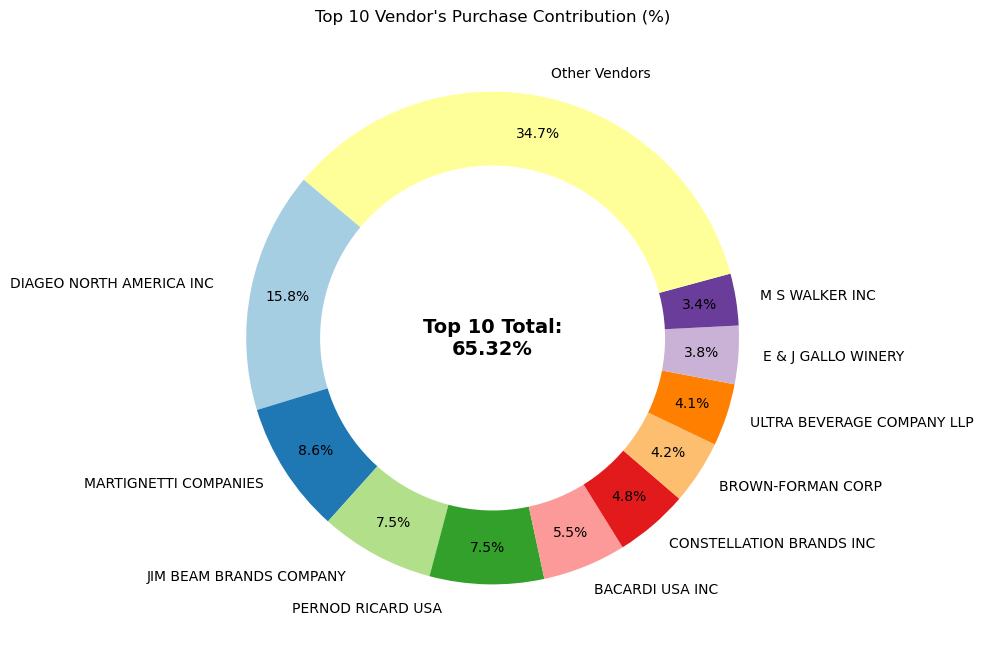

In [90]:
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['PurchaseContribution%'].values)

total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(0, 0, f"Top 10 Total:\n{total_contribution:.2f}%", 
         fontsize=14, fontweight='bold', ha='center', va='center')

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()

Does purchasing in bulk reduce the unit price, and what is the optimal purchase volume for cost savings?

In [91]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars']/df['TotalPurchaseQuantity']

In [92]:
df['OrderSize'] = pd.qcut(df['TotalPurchaseQuantity'], q=3, labels=["Small","Medium","Large"])


In [93]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,43.776954
Medium,17.894005
Large,11.308807


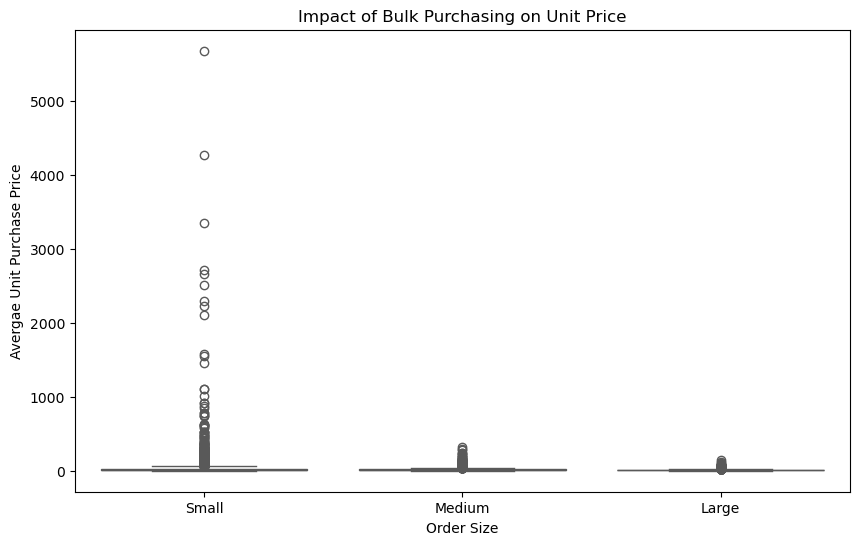

In [96]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='OrderSize', y='UnitPurchasePrice', palette='Set2')
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Avergae Unit Purchase Price")
plt.show()

Which vendors have low inventory turnover, indicating excess stock and slow-moving products?

In [101]:
df['StockTurnover'] = df['TotalSalesQuantity']/df['TotalPurchaseQuantity']

In [102]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover', ascending = True).head(10)

,StockTurnover
VendorName,
MANGO BOTTLING INC,0.007681
SWEETWATER FARM,0.026786
CALEDONIA SPIRITS INC,0.033420
TAMWORTH DISTILLING,0.034903
APPOLO VINEYARDS LLC,0.035227
WEIN BAUER INC,0.035812
BULLY BOY DISTILLERS,0.037507
CENTEUR IMPORTS LLC,0.046484
ALTAMAR BRANDS LLC,0.046875


How much capital is locked in unsold inventory per vendor, and which vendor contribute the most to it?

In [104]:
df['UnsoldInventoryValue'] = (df['TotalPurchaseQuantity'] - df['TotalSalesQuantity'])*df['PurchasePrice']
print('Total Unsold Capital:',format_dollars(df['UnsoldInventoryValue'].sum()))

Total Unsold Capital: 28.04M


In [105]:
# Aggregated capital locked per vendor
inventory_value_per_vendor = df.groupby('VendorName')['UnsoldInventoryValue'].sum().reset_index()

In [106]:
# Sort vendors with the Highest locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by = "UnsoldInventoryValue",ascending = False)
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
28,DIAGEO NORTH AMERICA INC,4.60M
63,MARTIGNETTI COMPANIES,2.31M
75,PERNOD RICARD USA,2.23M
50,JIM BEAM BRANDS COMPANY,2.14M
8,BACARDI USA INC,1.63M
23,CONSTELLATION BRANDS INC,1.41M
14,BROWN-FORMAN CORP,1.23M
33,E & J GALLO WINERY,1.09M
115,ULTRA BEVERAGE COMPANY LLP,9997.93K
68,MOET HENNESSY USA INC,8659.49K


What is the 95% confidence intervals for profit margins of the top-performing and low-performing vendors.

In [119]:
top_threshold = df['TotalSalesDollars'].quantile(0.75)
low_threshold = df['TotalSalesDollars'].quantile(0.25)

In [120]:
top_threshold = df[df['TotalSalesDollars'] >= top_threshold]['profitMargin'].dropna()
low_threshold = df[df['TotalSalesDollars'] <= low_threshold]['profitMargin'].dropna()

In [121]:
top_threshold

0      -10.255340
1      -13.351388
2      -11.293135
3       -6.909499
4       -8.168844
          ...    
8267    -6.328319
8628    -9.998745
8899     0.625638
9112    -1.005391
9356   -27.294693
Name: profitMargin, Length: 1786, dtype: float64

In [122]:
low_threshold

19      -64289.385872
718      -1159.394914
739      -1273.526316
781       -537.604149
869      -1101.877959
             ...     
10686   -10762.605946
10687    -4538.874372
10688     -800.912628
10690   -21526.097152
10691     -485.288689
Name: profitMargin, Length: 1786, dtype: float64

In [141]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

In [142]:
df_clean = df.copy()

# ensure numeric
df_clean['profitMargin'] = pd.to_numeric(df_clean['profitMargin'], errors='coerce')

# remove NaN
df_clean = df_clean.dropna(subset=['profitMargin'])

In [143]:
vendors = df_clean.groupby('VendorName').agg({
    'TotalSalesDollars': 'sum',
    'profitMargin': 'mean'
}).reset_index()

In [144]:
# Top vendors (high sales)
top_vendors = vendors.sort_values(by='TotalSalesDollars', ascending=False).head(10)

# Low vendors (low profit margin) 🔥 better logic
low_vendors = vendors.sort_values(by='profitMargin', ascending=True).head(10)

In [145]:
top_pm = top_vendors['profitMargin']
low_pm = low_vendors['profitMargin']

top_mean, top_lower, top_upper = confidence_interval(top_pm)
low_mean, low_lower, low_upper = confidence_interval(low_pm)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

Top Vendors 95% CI: (-787.12, -282.32), Mean: -534.72
Low Vendors 95% CI: (-811.71, -341.79), Mean: -576.75


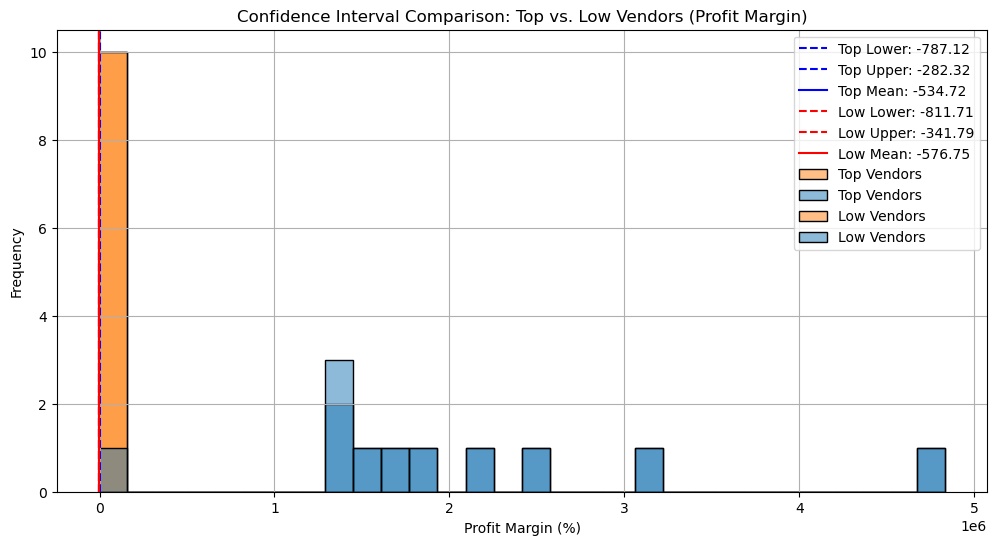

In [149]:
plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=False, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=False, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

Is there a significant difference in profit margins between top-performing and low-performing vendors?

Hypothesis: 
Ho(Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-performing vendors.
H1(Alternative Hypothesis): The mean profit margins of top-performing and low-performing vendors are significantly different.

In [151]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["profitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["profitMargin"].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H0: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H0: No significant difference in profit margins.")

T-Statistic: 11.9313, P-Value: 0.0000
Reject H0: There is a significant difference in profit margins between top and low-performing vendors.
